# Travel Reimbursement Approval Agent

## README

### Overview
This notebook implements a **single CrewAI agent** called **Travel Reimbursement Approval Agent**. The agent reviews travel claims using policy context and tools, then asks Gemini to produce the final reimbursement decision in structured JSON.

### Setup Steps
1. Create a Python environment.
2. Install dependencies.
3. Set `GEMINI_API_KEY` if you want Gemini-powered decisions.
4. Run the notebook top-to-bottom.

### How to Run the Demo
Open the notebook in Jupyter and run all cells. The notebook loads the policy and claims, runs policy/receipt/limit tools, asks the LLM to approve or reject each claim, validates the output, and shows a dashboard.

### Key Design Choices
- Single agent only.
- LLM makes the final decision.
- Tools provide evidence.
- Manual Review is preferred for ambiguous cases.
- Deterministic fallback keeps the notebook runnable without an API key.

In [6]:
import os, json
from datetime import datetime, date
from typing import Any, Dict, List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

# Load the variables from the .env file into the environment
load_dotenv()


True

In [7]:
USE_CREWAI = False
USE_GEMINI = bool(os.getenv('GEMINI_API_KEY'))
try:
    from crewai import Agent, Task, Crew
    from crewai import LLM
    USE_CREWAI = True
except Exception as e:
    print('CrewAI not available:', e)
print('USE_CREWAI =', USE_CREWAI)
print('USE_GEMINI =', USE_GEMINI)

USE_CREWAI = True
USE_GEMINI = True


In [8]:
POLICY = {
    "POL-CAT-01": "Eligible categories: airfare (economy only), lodging, meals, ground transport, conference fees.",
    "POL-CAT-02": "Ineligible items: alcohol, minibar, spa, gym, entertainment, gifts, fines, personal expenses.",
    "POL-PD-01": "Meals maximum $75 per day.",
    "POL-PD-02": "Lodging maximum $200 per night.",
    "POL-PD-03": "Ground transport maximum $50 per day.",
    "POL-AIR-01": "Only economy airfare is reimbursable. Business/first class must go to Manual Review.",
    "POL-RCT-01": "Any single line item > $25 needs a receipt. Airfare and lodging always need a receipt.",
    "POL-RCT-02": "Missing required receipt means Manual Review, not silent rejection.",
    "POL-APR-01": "Total <= $500 may be auto-approved if fully compliant.",
    "POL-APR-02": "Total > $500 and <= $2,000 can be approved if fully compliant.",
    "POL-APR-03": "Total > $2,000 must go to Manual Review.",
    "POL-TIME-01": "Claims must be submitted within 30 days of the expense date."
}
CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 420.0,
                "receipt": True,
                "economy": True,
                "days": 1
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $180",
                "amount": 360.0,
                "receipt": True,
                "nights": 2
            },
            {
                "category": "meals",
                "description": "Meals, 3 days @ ~$60/day",
                "amount": 180.0,
                "receipt": True,
                "days": 3
            },
            {
                "category": "conference_fees",
                "description": "Conference registration",
                "amount": 150.0,
                "receipt": True
            }
        ]
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "items": [
            {
                "category": "spa",
                "description": "Hotel spa package",
                "amount": 300.0,
                "receipt": True
            },
            {
                "category": "minibar",
                "description": "In-room minibar",
                "amount": 80.0,
                "receipt": True
            }
        ]
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 300.0,
                "receipt": True,
                "economy": True,
                "days": 1
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $250",
                "amount": 500.0,
                "receipt": True,
                "nights": 2
            },
            {
                "category": "meals",
                "description": "Meals, 2 days @ $70/day",
                "amount": 140.0,
                "receipt": True,
                "days": 2
            }
        ]
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "items": [
            {
                "category": "airfare",
                "description": "Business-class international airfare",
                "amount": 2400.0,
                "receipt": True,
                "economy": False,
                "days": 1
            },
            {
                "category": "lodging",
                "description": "Hotel, 3 nights",
                "amount": 600.0,
                "receipt": False,
                "nights": 3
            }
        ]
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "items": [
            {
                "category": "meals",
                "description": "Client dinner for 4 (business development)",
                "amount": 220.0,
                "receipt": False,
                "days": 1
            }
        ]
    }
]

def parse_date(s: str) -> date:
    return datetime.strptime(s, '%Y-%m-%d').date()

In [9]:
def policy_lookup_tool(claim: Dict[str, Any]) -> Dict[str, Any]:
    cats = {item["category"] for item in claim["items"]}
    refs = {"POL-APR-01", "POL-APR-02", "POL-APR-03", "POL-TIME-01"}
    if "airfare" in cats: refs.add("POL-AIR-01")
    if "lodging" in cats: refs.update({"POL-PD-02", "POL-RCT-01"})
    if "meals" in cats: refs.update({"POL-PD-01", "POL-RCT-01"})
    if "conference_fees" in cats: refs.add("POL-CAT-01")
    if any(c in {"spa", "minibar"} for c in cats): refs.add("POL-CAT-02")
    return {"policy_refs": sorted(refs), "policy_text": {r: POLICY[r] for r in sorted(refs)}}

def receipt_validation_tool(claim: Dict[str, Any]) -> Dict[str, Any]:
    missing = []
    for item in claim["items"]:
        cat = item["category"]
        amt = float(item["amount"])
        receipt = bool(item.get("receipt", False))
        needs_receipt = cat in {"airfare", "lodging"} or amt > 25
        if needs_receipt and not receipt:
            if cat == "airfare":
                missing.append("Airfare receipt")
            elif cat == "lodging":
                missing.append("Lodging receipt")
            else:
                missing.append(f"{cat} receipt")
    return {"receipt_ok": len(missing) == 0, "missing_docs": missing}

def limit_checker_tool(claim: Dict[str, Any]) -> Dict[str, Any]:
    approved, deducted = 0.0, 0.0
    manual = False
    reasons = []
    if (parse_date(claim["submitted"]) - parse_date(claim["trip_end"])).days > 30:
        manual = True
        reasons.append("Late submission beyond 30 days")
    for item in claim["items"]:
        cat = item["category"]
        amt = float(item["amount"])
        if cat in {"spa", "minibar", "alcohol", "entertainment", "gifts", "personal_shopping", "fines"}:
            deducted += amt
            reasons.append("Ineligible category detected")
        elif cat == "airfare":
            if not item.get("economy", True):
                manual = True
                reasons.append("Business/first-class airfare requires Manual Review")
            else:
                approved += amt
        elif cat == "lodging":
            cap = 200.0 * int(item.get("nights", 1))
            approved += min(amt, cap)
            deducted += max(0.0, amt - cap)
            if amt > cap:
                reasons.append("Lodging exceeded nightly cap")
        elif cat == "meals":
            cap = 75.0 * int(item.get("days", 1))
            approved += min(amt, cap)
            deducted += max(0.0, amt - cap)
            if amt > cap:
                reasons.append("Meals exceeded per-diem")
        elif cat == "ground_transport":
            cap = 50.0 * int(item.get("days", 1))
            approved += min(amt, cap)
            deducted += max(0.0, amt - cap)
            if amt > cap:
                reasons.append("Ground transport exceeded cap")
        else:
            approved += amt
    if approved > 2000:
        manual = True
        reasons.append("Total reimbursable amount exceeds director threshold")
    return {"approved_amount": round(approved, 2), "deducted_amount": round(deducted, 2), "manual_review_needed": manual, "review_reasons": sorted(set(reasons))}

def output_validator_tool(result: Dict[str, Any]) -> Tuple[bool, List[str]]:
    required = {"claim_id", "decision", "approved_amount", "deducted_amount", "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"}
    allowed = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}
    issues = []
    missing = required - set(result.keys())
    if missing:
        issues.append(f"Missing keys: {sorted(missing)}")
    if result.get("decision") not in allowed:
        issues.append(f"Invalid decision: {result.get('decision')}")
    if not isinstance(result.get("missing_docs"), list):
        issues.append("missing_docs must be a list")
    if not isinstance(result.get("policy_refs"), list):
        issues.append("policy_refs must be a list")
    if not isinstance(result.get("tools_used"), list):
        issues.append("tools_used must be a list")
    return len(issues) == 0, issues

In [10]:
def fallback_decision(claim: Dict[str, Any]) -> Dict[str, Any]:
    policy_out = policy_lookup_tool(claim)
    receipt_out = receipt_validation_tool(claim)
    limit_out = limit_checker_tool(claim)
    total_claimed = round(sum(float(i["amount"]) for i in claim["items"]), 2)
    ineligible_only = all(i["category"] in {"spa", "minibar", "alcohol", "entertainment", "gifts", "personal_shopping", "fines"} for i in claim["items"])
    if ineligible_only:
        result = {"claim_id": claim["claim_id"], "decision": "REJECT", "approved_amount": 0.0, "deducted_amount": total_claimed, "missing_docs": [], "policy_refs": policy_out["policy_refs"], "confidence": 0.98, "explanation": "All line items are ineligible under POL-CAT-02.", "tools_used": ["policy_lookup_tool", "receipt_validation_tool", "limit_checker_tool", "output_validator_tool"]}
    elif receipt_out["missing_docs"] or limit_out["manual_review_needed"]:
        result = {"claim_id": claim["claim_id"], "decision": "MANUAL_REVIEW", "approved_amount": 0.0, "deducted_amount": 0.0, "missing_docs": receipt_out["missing_docs"], "policy_refs": policy_out["policy_refs"], "confidence": 0.86 if receipt_out["missing_docs"] else 0.82, "explanation": "; ".join(limit_out["review_reasons"] + (["Missing required receipt(s)"] if receipt_out["missing_docs"] else [])), "tools_used": ["policy_lookup_tool", "receipt_validation_tool", "limit_checker_tool", "output_validator_tool"]}
    elif limit_out["deducted_amount"] > 0:
        result = {"claim_id": claim["claim_id"], "decision": "PARTIAL_APPROVE", "approved_amount": limit_out["approved_amount"], "deducted_amount": limit_out["deducted_amount"], "missing_docs": [], "policy_refs": policy_out["policy_refs"], "confidence": 0.96, "explanation": "Some items exceeded policy caps and were deducted.", "tools_used": ["policy_lookup_tool", "receipt_validation_tool", "limit_checker_tool", "output_validator_tool"]}
    else:
        result = {"claim_id": claim["claim_id"], "decision": "APPROVE", "approved_amount": limit_out["approved_amount"], "deducted_amount": limit_out["deducted_amount"], "missing_docs": [], "policy_refs": policy_out["policy_refs"], "confidence": 0.97, "explanation": "The claim is fully compliant and within the approval tier.", "tools_used": ["policy_lookup_tool", "receipt_validation_tool", "limit_checker_tool", "output_validator_tool"]}
    ok, issues = output_validator_tool(result)
    if not ok:
        raise ValueError(f"Output validation failed for {claim['claim_id']}: {issues}")
    return result

In [11]:
from crewai import Agent, Task, Crew, LLM
import os
import json

async def gemini_approve(claim):
    policy_out = policy_lookup_tool(claim)
    receipt_out = receipt_validation_tool(claim)
    limit_out = limit_checker_tool(claim)

    llm = LLM(
        model="gemini/gemini-3.1-flash-lite",
        api_key=os.getenv("GEMINI_API_KEY"),
        temperature=0.1,
    )

    agent = Agent(
        role="Travel Reimbursement Approval Agent",
        goal="Evaluate travel claims using policy context and tools, then produce the final reimbursement decision.",
        backstory=(
            "You are a strict reimbursement reviewer. "
            "You must ground every decision in policy IDs, prefer Manual Review for ambiguity, "
            "and return exact JSON only."
        ),
        llm=llm,
        verbose=False,
    )

    prompt = f"""
Return ONLY valid JSON with exactly these keys:
claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used

Allowed decision values:
APPROVE, PARTIAL_APPROVE, REJECT, MANUAL_REVIEW

Claim:
{json.dumps(claim, indent=2)}

Policy references:
{json.dumps(policy_out, indent=2)}

Receipt check:
{json.dumps(receipt_out, indent=2)}

Limit check:
{json.dumps(limit_out, indent=2)}

Rules:
- Use the tool outputs as evidence.
- If any required receipt is missing, use MANUAL_REVIEW.
- If business-class airfare appears, use MANUAL_REVIEW.
- If the claim is entirely ineligible, use REJECT.
- If only some amounts exceed caps, use PARTIAL_APPROVE.
- Otherwise use APPROVE.
- tools_used must include the tools that informed the decision.
"""

    task = Task(
        description=prompt,
        expected_output="A single JSON object.",
        agent=agent,
    )

    crew = Crew(
        agents=[agent],
        tasks=[task],
        verbose=False,
    )

    raw = await crew.kickoff_async()
    raw_text = str(raw).strip()

    try:
        result = json.loads(raw_text)
    except Exception:
        return fallback_decision(claim)

    ok, issues = output_validator_tool(result)
    if not ok:
        return fallback_decision(claim)

    return result

In [12]:
results = []
for claim in CLAIMS:
    res = await gemini_approve(claim)
    results.append(res)

print(json.dumps(results, indent=2))

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 1.0,
    "explanation": "The claim total of $1,110.00 falls within the $500-$2,000 range (POL-APR-02). All items are within eligible categories (POL-CAT-01), meal expenses are within the $75/day limit (POL-PD-01), lodging is within the $200/night limit (POL-PD-02), airfare is economy (POL-AIR-01), all receipts are provided (POL-RCT-01), and the submission is within the 30-day window (POL-TIME-01).",
    "tools_used": [
      "Receipt check",
      "Limit check"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confi

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Dashboard

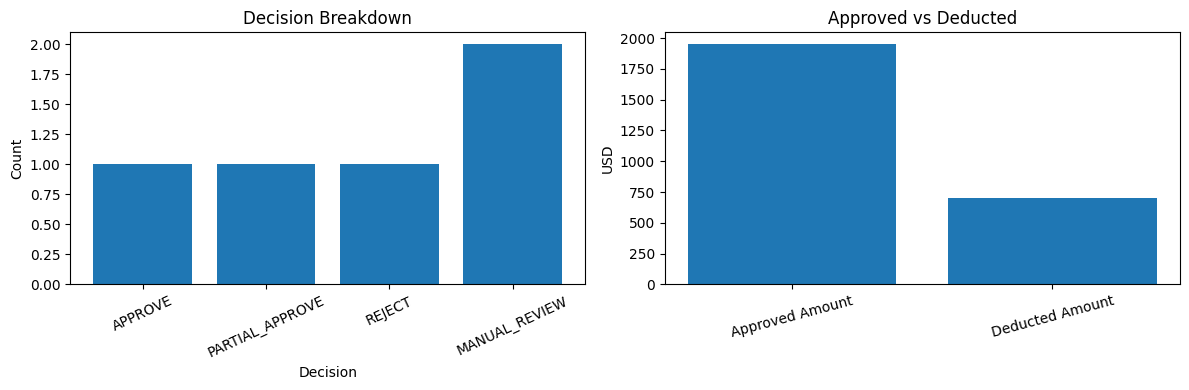

In [13]:
df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
counts = df["decision"].value_counts().reindex(order, fill_value=0)
axes[0].bar(counts.index, counts.values)
axes[0].set_title("Decision Breakdown")
axes[0].set_xlabel("Decision")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=25)
axes[1].bar(["Approved Amount", "Deducted Amount"], [df["approved_amount"].sum(), df["deducted_amount"].sum()])
axes[1].set_title("Approved vs Deducted")
axes[1].set_ylabel("USD")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("dashboard.png", dpi=160, bbox_inches="tight")
plt.show()

## Sample Outputs

In [14]:
print(json.dumps(results[:3], indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 1.0,
    "explanation": "The claim total of $1,110.00 falls within the $500-$2,000 range (POL-APR-02). All items are within eligible categories (POL-CAT-01), meal expenses are within the $75/day limit (POL-PD-01), lodging is within the $200/night limit (POL-PD-02), airfare is economy (POL-AIR-01), all receipts are provided (POL-RCT-01), and the submission is within the 30-day window (POL-TIME-01).",
    "tools_used": [
      "Receipt check",
      "Limit check"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confi

## Assumptions and Limitations

- The provided policy is the source of truth.
- Missing receipts, policy exceptions, late submissions, and high-value claims go to Manual Review.
- The notebook includes a deterministic fallback so it still runs without an API key.

In [15]:
print(json.dumps(results, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 1.0,
    "explanation": "The claim total of $1,110.00 falls within the $500-$2,000 range (POL-APR-02). All items are within eligible categories (POL-CAT-01), meal expenses are within the $75/day limit (POL-PD-01), lodging is within the $200/night limit (POL-PD-02), airfare is economy (POL-AIR-01), all receipts are provided (POL-RCT-01), and the submission is within the 30-day window (POL-TIME-01).",
    "tools_used": [
      "Receipt check",
      "Limit check"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confi